# 01 · Explore Raw Data Sources

**Goal:** Download each corpus, save raw records, then run unified analytics  
to understand structure and choose stratification axes for dataset design.

**Philosophy:** *save raw → analyse in memory*  
No deduplication or filtering when saving. Analytics is read-only.

**All collected files land in one folder:**
```
data/raw/collected/
  nazario.jsonl
  sms_spam.jsonl
  enron.jsonl
  spamassassin.jsonl
  hc3_finance.jsonl
  hc3_open_qa.jsonl
```

**Saved fields per record (where available)**
| field | type | source |
|---|---|---|
| `text` | str | extracted plain text — main analytics field |
| `label` / `role` | str | original class label |
| `subject` | str | email Subject header |
| `from` | str | email From header |
| `date` | str | email Date header |
| `source` | str | file/archive name |
| `has_url` | bool | any `http://` or `https://` in text |
| `url_count` | int | number of distinct URLs |
| `collection_period` | str | known era of the corpus |

**Sections:** 1 Nazario · 2 SMS Spam · 3 Enron · 4 SpamAssassin · 5 HC3 Finance · 6 HC3 Open QA · 7 Summary

> After running this notebook fill in `../../docs/dataset_design.md`.

In [67]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
import hashlib
import io
import json
import mailbox
import re
import tarfile
import tempfile
import textwrap
import warnings
import zipfile
from collections import Counter
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 130


def _find_v2_root() -> Path:
    notebook_path = globals().get("__vsc_ipynb_file__") or None
    start = Path(notebook_path).resolve().parent if notebook_path else Path().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(f"Cannot locate v2/ project root starting from {start}.")


V2_ROOT   = _find_v2_root()
RAW_DIR   = V2_ROOT / "data" / "raw"
COLLECTED = RAW_DIR / "collected"   # ← all raw JSONL files land here
OUT_FIGS  = V2_ROOT / "outputs" / "figures"
OUT_TABLES = V2_ROOT / "outputs" / "tables"

for d in [COLLECTED, OUT_FIGS, OUT_TABLES]:
    d.mkdir(parents=True, exist_ok=True)

print(f"V2_ROOT   : {V2_ROOT}")
print(f"COLLECTED : {COLLECTED}")

V2_ROOT   : /Users/askar/projects/antifraud-deepfake-detection/v2
COLLECTED : /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected


In [68]:
# ── Helpers ────────────────────────────────────────────────────────────────
import html as _html_module
import random
from html.parser import HTMLParser as _HTMLParser

_YEAR_RE = re.compile(r"\b(199[5-9]|200[0-9]|201[0-9]|202[0-9])\b")
_URL_RE  = re.compile(r"https?://[^\s<>\"']+")


# ── Email body extraction ─────────────────────────────────────────────────

class _TextExtractor(_HTMLParser):
    SKIP_TAGS = {"style", "script", "head"}
    def __init__(self):
        super().__init__(convert_charrefs=True)
        self._parts: list[str] = []
        self._skip_depth = 0
    def handle_starttag(self, tag, attrs):
        if tag.lower() in self.SKIP_TAGS:
            self._skip_depth += 1
    def handle_endtag(self, tag):
        if tag.lower() in self.SKIP_TAGS and self._skip_depth > 0:
            self._skip_depth -= 1
        elif tag.lower() in ("p", "br", "div", "tr", "li"):
            self._parts.append("\n")
    def handle_data(self, data):
        if self._skip_depth == 0:
            self._parts.append(data)
    def get_text(self) -> str:
        text = "".join(self._parts)
        lines = [" ".join(ln.split()) for ln in text.splitlines()]
        return "\n".join(ln for ln in lines if ln).strip()


def _html_to_text(html_str: str) -> str:
    p = _TextExtractor()
    try:
        p.feed(html_str)
        return p.get_text()
    except Exception:
        text = re.sub(r"<[^>]+>", " ", html_str)
        return _html_module.unescape(re.sub(r"\s+", " ", text)).strip()


def _sanitize(text: str) -> str:
    try:
        return text.encode("utf-8", errors="replace").decode("utf-8")
    except Exception:
        return text


def _decode_part(part) -> str:
    try:
        payload = part.get_payload(decode=True) or b""
        charset = part.get_content_charset() or "utf-8"
        return _sanitize(payload.decode(charset, errors="replace"))
    except Exception:
        return _sanitize(str(part.get_payload() or ""))


def extract_email_body(raw: str) -> str:
    """Extract readable plain text from a raw RFC-2822 email string."""
    from email import message_from_string
    try:
        msg = message_from_string(raw)
    except Exception:
        return _html_to_text(raw)
    plain_parts: list[str] = []
    html_parts:  list[str] = []
    if msg.is_multipart():
        for part in msg.walk():
            ct = part.get_content_type()
            if ct == "text/plain":
                plain_parts.append(_decode_part(part))
            elif ct == "text/html":
                html_parts.append(_html_to_text(_decode_part(part)))
    else:
        ct = msg.get_content_type()
        if ct == "text/plain":
            plain_parts.append(_decode_part(msg))
        elif ct == "text/html":
            html_parts.append(_html_to_text(_decode_part(msg)))
    chosen = plain_parts if plain_parts else html_parts
    return re.sub(r"\n{3,}", "\n\n", "\n".join(chosen).strip())


# ── Derived metadata helpers ───────────────────────────────────────────────

def url_meta(text: str) -> tuple[bool, int]:
    """Return (has_url, url_count) from plain text."""
    urls = _URL_RE.findall(text)
    return bool(urls), len(urls)


# ── JSONL I/O ─────────────────────────────────────────────────────────────

def save_jsonl(records: list[dict], path: Path) -> None:
    with open(path, "w") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=True) + "\n")
    print(f"Saved {len(records):,} records → {path}")


def load_jsonl(path: Path) -> list[dict]:
    return [json.loads(l) for l in path.read_text().splitlines() if l.strip()]


# ── Unified analytics ──────────────────────────────────────────────────────

def word_count(text: str) -> int:
    return len(text.split())


def analyze_source(
    records: list[dict],
    name: str,
    text_key: str = "text",
    label_key: str | None = None,
    n_samples: int = 3,
) -> None:
    """Unified analytics: count, dedup, encoding, length, labels, temporal, URL stats, samples."""
    n = len(records)
    if n == 0:
        print(f"{name}: ⚠️  no records")
        return

    sep = "=" * 70
    print(f"\n{sep}\n  {name}\n{sep}")

    # 1. Count + fields
    all_keys = sorted({k for r in records[:500] for k in r})
    print(f"Total records  : {n:,}")
    print(f"Fields         : {all_keys}")

    # 2. Dedup estimate (informational — files not modified)
    seen: set[str] = set()
    n_unique = sum(
        1 for r in records
        if (h := hashlib.md5(r[text_key].strip().encode("utf-8", errors="replace")).hexdigest())
        and not seen.__contains__(h) and not seen.add(h)
    )
    dup_rate = (n - n_unique) / max(n, 1)
    print(f"Unique texts   : {n_unique:,}  (dup rate {100*dup_rate:.1f}% — file unchanged)")

    # 3. Encoding quality
    n_noisy = sum(1 for r in records
                  if r[text_key].count("\ufffd") / max(len(r[text_key]), 1) > 0.02)
    n_short = sum(1 for r in records if word_count(r[text_key]) < 10)
    print(f"Noisy >2%\\ufffd : {n_noisy:,}  ({100*n_noisy/n:.1f}%)")
    print(f"Short <10 words: {n_short:,}  ({100*n_short/n:.1f}%)")

    # 4. URL stats
    n_has_url  = sum(1 for r in records if r.get("has_url", False))
    url_counts = [r.get("url_count", 0) for r in records]
    avg_urls   = sum(url_counts) / max(n, 1)
    print(f"Has URL        : {n_has_url:,}  ({100*n_has_url/n:.1f}%),  avg {avg_urls:.1f} URLs/record")

    # 5. Word-count distribution
    wcs = [word_count(r[text_key]) for r in records]
    s = pd.Series(wcs, name="n_words")
    print(f"\nWord count distribution:")
    display(s.describe(percentiles=[.10, .25, .5, .75, .90, .95]).round(1))

    fig, ax = plt.subplots(figsize=(9, 3))
    xlim = min(int(s.quantile(0.99)) + 50, 2000)
    ax.hist([min(w, xlim) for w in wcs], bins=60, alpha=0.75)
    ax.set_xlabel("Word count (clipped at 99th pct)")
    ax.set_title(f"{name} — word-count distribution")
    plt.tight_layout()
    safe = re.sub(r"[^\w]+", "_", name.lower())
    fig.savefig(OUT_FIGS / f"{safe}_wordcount.png")
    plt.show()

    # 6. Label distribution
    if label_key:
        lbl_counts = Counter(r.get(label_key, "?") for r in records)
        mx = max(lbl_counts.values())
        print(f"\nLabel ({label_key}):")
        for lbl, cnt in lbl_counts.most_common():
            bar = "█" * max(1, cnt * 40 // mx)
            print(f"  {str(lbl):<20} {cnt:>6,}  ({100*cnt/n:5.1f}%)  {bar}")

    # 7. Temporal distribution
    years: list[int] = []
    for r in records:
        for field in ("date", "collection_period", "source", "archive", "subset"):
            m = _YEAR_RE.search(str(r.get(field, "")))
            if m:
                years.append(int(m.group()))
                break
    if years:
        yr_c = Counter(years)
        mx   = max(yr_c.values())
        print(f"\nTemporal ({len(years):,}/{n:,} records dated,  span {min(yr_c)}–{max(yr_c)}):")
        for y in sorted(yr_c):
            bar = "█" * max(1, yr_c[y] * 40 // mx)
            print(f"  {y}: {yr_c[y]:>5,}  {bar}")
    else:
        print("\nTemporal: no parseable year found in metadata")

    # 8. Subject / From stats (email sources)
    if any("subject" in r for r in records[:20]):
        has_subj = sum(1 for r in records if r.get("subject", "").strip())
        has_from = sum(1 for r in records if r.get("from",    "").strip())
        print(f"\nEmail headers  — subject: {has_subj:,}/{n:,}   from: {has_from:,}/{n:,}")

    # 9. Samples
    print(f"\n{'─'*25}  {n_samples} random samples  {'─'*25}")
    for i, r in enumerate(random.sample(records, min(n_samples, n)), 1):
        txt  = r[text_key]
        wc   = word_count(txt)
        meta = {k: v for k, v in r.items() if k != text_key}
        print(f"\n── {i}  [{wc}w]  {meta}")
        print(textwrap.fill(txt[:400], width=100))
        if len(txt) > 400:
            print("  [...]")


print("Helpers ready.")

Helpers ready.


---
## 1 · Nazario Phishing Corpus

**Source:** http://monkey.org/~jose/phishing/  
**Format:** mbox archives — legacy (2005–2007) + yearly archives 2015–2025  
**Candidate role:** Human + Fraud → `phishing_email`  

**Stratification axes available:**
- `date` header → per-record year 2000–2025 → **era bin**
- `subject` → topic/lure type
- `has_url` → URL intensity in phishing
- `url_count` → URL density
- `source` file → era grouping (pre-2010 / 2015+)

In [69]:
# ── 1a. Download & parse Nazario ──────────────────────────────────────────
NAZ_CACHE = COLLECTED / "nazario.jsonl"

NAZARIO_BASE  = "https://monkey.org/~jose/phishing"
NAZARIO_FILES = [
    "20051114.mbox", "phishing0.mbox", "phishing1.mbox",
    "phishing2.mbox", "phishing3.mbox",
    "phishing-2015", "phishing-2016", "phishing-2017", "phishing-2018",
    "phishing-2019", "phishing-2020", "phishing-2021", "phishing-2022",
    "phishing-2023", "phishing-2024", "phishing-2025",
]


def _parse_mbox_bytes(data: bytes, fname: str) -> list[dict]:
    records = []
    with tempfile.NamedTemporaryFile(suffix=".mbox", delete=False) as tmp:
        tmp.write(data)
        tmp_path = Path(tmp.name)
    try:
        for msg in mailbox.mbox(str(tmp_path)):
            try:
                body = extract_email_body(msg.as_string()).strip()
            except Exception:
                continue
            has_url, n_url = url_meta(body)
            records.append({
                "text":      body,
                "subject":   _sanitize(str(msg.get("Subject", ""))),
                "from":      _sanitize(str(msg.get("From", ""))),
                "date":      str(msg.get("Date", "")),
                "source":    fname,
                "has_url":   has_url,
                "url_count": n_url,
            })
    finally:
        tmp_path.unlink(missing_ok=True)
    return records


if NAZ_CACHE.exists():
    print(f"Cache: {NAZ_CACHE}")
    nazario_records = load_jsonl(NAZ_CACHE)
else:
    nazario_records = []
    for fname in NAZARIO_FILES:
        print(f"  {fname} ...", end=" ", flush=True)
        try:
            resp = httpx.get(f"{NAZARIO_BASE}/{fname}", timeout=120, follow_redirects=True)
            resp.raise_for_status()
        except Exception as e:
            print(f"FAILED ({e})"); continue
        batch = _parse_mbox_bytes(resp.content, fname)
        nazario_records.extend(batch)
        print(f"{len(batch):,} msgs  (total {len(nazario_records):,})")
    save_jsonl(nazario_records, NAZ_CACHE)

print(f"\nNazario raw total: {len(nazario_records):,}")

  20051114.mbox ... 438 msgs  (total 438)
  phishing0.mbox ... 414 msgs  (total 852)
  phishing1.mbox ... 456 msgs  (total 1,308)
  phishing2.mbox ... 1,422 msgs  (total 2,730)
  phishing3.mbox ... 2,279 msgs  (total 5,009)
  phishing-2015 ... 307 msgs  (total 5,316)
  phishing-2016 ... 494 msgs  (total 5,810)
  phishing-2017 ... 324 msgs  (total 6,134)
  phishing-2018 ... 287 msgs  (total 6,421)
  phishing-2019 ... 242 msgs  (total 6,663)
  phishing-2020 ... 158 msgs  (total 6,821)
  phishing-2021 ... 101 msgs  (total 6,922)
  phishing-2022 ... 247 msgs  (total 7,169)
  phishing-2023 ... 419 msgs  (total 7,588)
  phishing-2024 ... 403 msgs  (total 7,991)
  phishing-2025 ... 481 msgs  (total 8,472)
Saved 8,472 records → /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected/nazario.jsonl

Nazario raw total: 8,472



  Nazario Phishing
Total records  : 8,472
Fields         : ['date', 'from', 'has_url', 'source', 'subject', 'text', 'url_count']
Unique texts   : 5,820  (dup rate 31.3% — file unchanged)
Noisy >2%\ufffd : 31  (0.4%)
Short <10 words: 498  (5.9%)
Has URL        : 4,026  (47.5%),  avg 1.0 URLs/record

Word count distribution:


count     8472.0
mean       170.8
std        535.9
min          0.0
10%         25.0
25%         63.0
50%        136.0
75%        235.0
90%        329.0
95%        366.0
max      46576.0
Name: n_words, dtype: float64

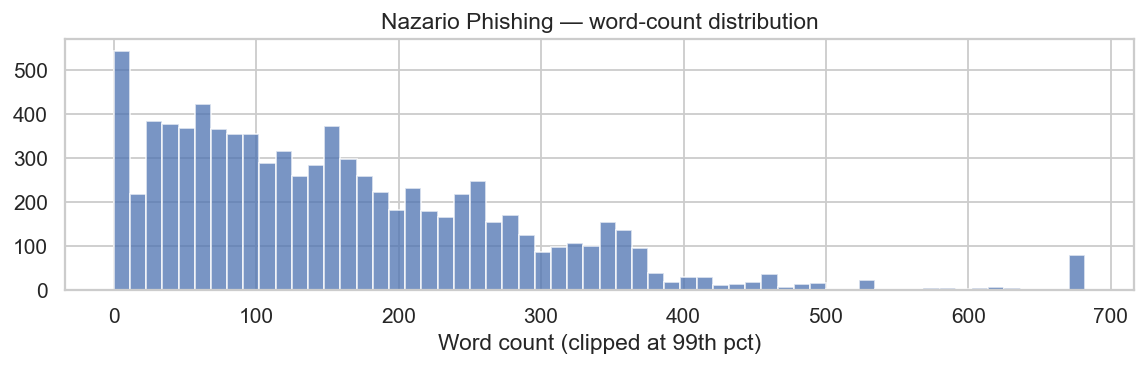


Label (source):
  phishing3.mbox        2,279  ( 26.9%)  ████████████████████████████████████████
  phishing2.mbox        1,422  ( 16.8%)  ████████████████████████
  phishing-2016           494  (  5.8%)  ████████
  phishing-2025           481  (  5.7%)  ████████
  phishing1.mbox          456  (  5.4%)  ████████
  20051114.mbox           438  (  5.2%)  ███████
  phishing-2023           419  (  4.9%)  ███████
  phishing0.mbox          414  (  4.9%)  ███████
  phishing-2024           403  (  4.8%)  ███████
  phishing-2017           324  (  3.8%)  █████
  phishing-2015           307  (  3.6%)  █████
  phishing-2018           287  (  3.4%)  █████
  phishing-2022           247  (  2.9%)  ████
  phishing-2019           242  (  2.9%)  ████
  phishing-2020           158  (  1.9%)  ██
  phishing-2021           101  (  1.2%)  █

Temporal (8,314/8,472 records dated,  span 1999–2025):
  1999:     1  █
  2000:     5  █
  2001:     3  █
  2002:    17  █
  2003:    33  █
  2004:    73  █
  2005: 1,5

In [70]:
# ── 1b. Analyze Nazario ───────────────────────────────────────────────────
analyze_source(nazario_records, "Nazario Phishing", label_key="source")

print("\n── Stratification notes ──────────────────────────────────────────────")
print("  ✅ Axis: YEAR (Date header) — per-record year 2000–2025")
print("  ✅ Axis: HAS_URL / URL_COUNT — phishing typically URL-heavy")
print("  ✅ Axis: SUBJECT — lure type (bank, parcel, account, etc.)")
print("  Role: Group A (Human+Fraud) → phishing_email")
print("  ⚠️  Temporal gap: include 2015–2025 files to narrow gap vs LLM 2024–2025")

---
## 2 · SMS Spam Collection (UCI)

**Source:** https://archive.ics.uci.edu/dataset/228/sms+spam+collection  
**Reference:** Almeida & Hidalgo 2011  
**Collection period:** 2006–2012  
**Candidate roles:**
- `spam` → Human + Fraud → `smishing`
- `ham`  → Human + Legit → `legitimate_sms`

**Stratification axes available:**
- `label` (spam/ham) — clean binary
- `has_url` / `url_count` — presence of shortened URLs typical in smishing
- text length — SMS naturally short → validates short-text length bin

In [71]:
# ── 2a. Download SMS Spam Collection ─────────────────────────────────────
SMS_CACHE = COLLECTED / "sms_spam.jsonl"
SMS_URL   = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

if SMS_CACHE.exists():
    print(f"Cache: {SMS_CACHE}")
    sms_records = load_jsonl(SMS_CACHE)
else:
    print("Downloading SMS Spam Collection ...")
    resp = httpx.get(SMS_URL, timeout=60, follow_redirects=True)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        data_name = next(n for n in zf.namelist() if "SMSSpamCollection" in n)
        lines = zf.read(data_name).decode("utf-8", errors="replace").splitlines()
    sms_records = []
    for line in lines:
        if "\t" not in line:
            continue
        lbl, text = line.split("\t", 1)
        text = text.strip()
        has_url, n_url = url_meta(text)
        sms_records.append({
            "text":              text,
            "label":             lbl.strip(),
            "has_url":           has_url,
            "url_count":         n_url,
            "collection_period": "2006-2012",
        })
    save_jsonl(sms_records, SMS_CACHE)

print(f"SMS raw total: {len(sms_records):,}")

Saved 5,574 records → /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected/sms_spam.jsonl
SMS raw total: 5,574



  SMS Spam Collection
Total records  : 5,574
Fields         : ['collection_period', 'has_url', 'label', 'text', 'url_count']
Unique texts   : 5,160  (dup rate 7.4% — file unchanged)
Noisy >2%\ufffd : 0  (0.0%)
Short <10 words: 2,152  (38.6%)
Has URL        : 19  (0.3%),  avg 0.0 URLs/record

Word count distribution:


count    5574.0
mean       15.6
std        11.4
min         1.0
10%         5.0
25%         7.0
50%        12.0
75%        23.0
90%        29.0
95%        33.0
max       171.0
Name: n_words, dtype: float64

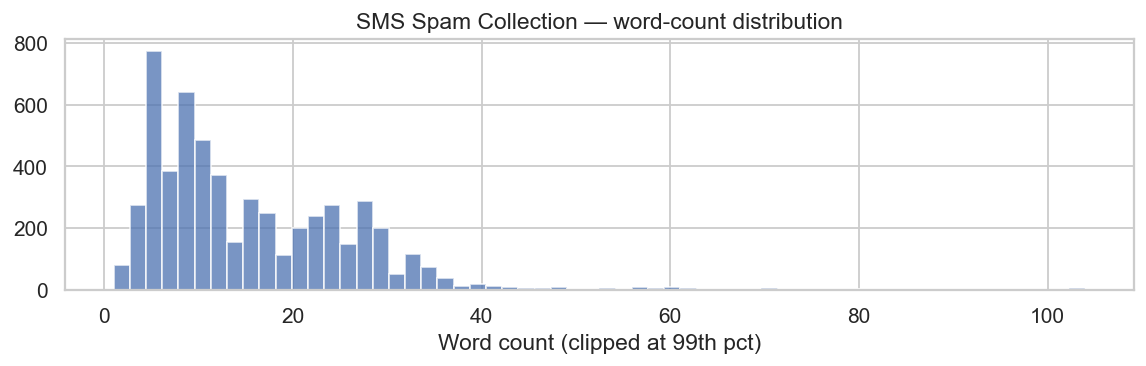


Label (label):
  ham                   4,827  ( 86.6%)  ████████████████████████████████████████
  spam                    747  ( 13.4%)  ██████

Temporal (5,574/5,574 records dated,  span 2006–2006):
  2006: 5,574  ████████████████████████████████████████

─────────────────────────  3 random samples  ─────────────────────────

── 1  [10w]  {'label': 'ham', 'has_url': False, 'url_count': 0, 'collection_period': '2006-2012'}
Yeah, don't go to bed, I'll be back before midnight

── 2  [29w]  {'label': 'spam', 'has_url': False, 'url_count': 0, 'collection_period': '2006-2012'}
Urgent Urgent! We have 800 FREE flights to Europe to give away, call B4 10th Sept & take a friend 4
FREE. Call now to claim on 09050000555. BA128NNFWFLY150ppm

── 3  [5w]  {'label': 'ham', 'has_url': False, 'url_count': 0, 'collection_period': '2006-2012'}
Went fast asleep dear.take care.

── SMS spam theme breakdown ──
  prize/lottery            353  (47.3%)
  other                    262  (35.1%)
  adult/dating   

In [72]:
# ── 2b. Analyze SMS ───────────────────────────────────────────────────────
analyze_source(sms_records, "SMS Spam Collection", label_key="label")

# Theme breakdown of spam messages
THEME_KW = {
    "prize/lottery":    ["won", "winner", "prize", "lottery", "free", "claim"],
    "account/security": ["account", "verify", "bank", "card", "password", "login"],
    "adult/dating":     ["sexy", "girl", "dating", "adult", "xxx", "horny"],
    "financial_offer":  ["loan", "credit", "cash", "earn", "income"],
    "delivery":         ["parcel", "delivery", "package", "courier", "collect"],
}
sms_spam = [r for r in sms_records if r["label"] == "spam"]
theme_counts: Counter = Counter()
for r in sms_spam:
    tl = r["text"].lower()
    for theme, kws in THEME_KW.items():
        if any(k in tl for k in kws):
            theme_counts[theme] += 1
            break
    else:
        theme_counts["other"] += 1
print("\n── SMS spam theme breakdown ──")
for t, cnt in theme_counts.most_common():
    print(f"  {t:<22} {cnt:>5,}  ({100*cnt/max(len(sms_spam),1):.1f}%)")

print("\n── Stratification notes ──────────────────────────────────────────────")
print("  ✅ Axis: LABEL (spam/ham)")
print("  ✅ Axis: THEME (heuristic) — prize, financial, delivery…")
print("  ✅ Axis: HAS_URL — shortened URLs typical in smishing")
print("  Role: spam→A smishing,  ham→B legitimate_sms")
print("  ⚠️  No per-record date; collection 2006–2012")

---
## 3 · Enron-Spam

**Source:** http://www2.aueb.gr/users/ion/data/enron-spam/ (Metsis et al. 2006)  
**Format:** 6 tar.gz archives, `spam/` + `ham/` folders  
**Collection period:** ~2000–2002 (pre-bankruptcy Enron emails)

**Candidate roles:**
- spam with 419 keywords → `scam_419`
- ham → `legitimate_email`

**Stratification axes available:**
- `label` (spam/ham)
- `subject` / `from` headers
- `has_url` / `url_count`
- 419-style keyword sub-filter → `scam_419` sub-corpus
- ⚠️  Era 2000–2002: highest temporal-bias risk

In [73]:
# ── 3a. Download Enron-Spam ───────────────────────────────────────────────
ENR_CACHE = COLLECTED / "enron.jsonl"
ENRON_URL_PATTERNS = [
    "http://www.aueb.gr/users/ion/data/enron-spam/preprocessed/{name}.tar.gz",
    "http://www2.aueb.gr/users/ion/data/enron-spam/preprocessed/{name}.tar.gz",
]
ENRON_SUBSETS = ["enron1", "enron2", "enron3", "enron4", "enron5", "enron6"]


def _try_dl(name: str) -> bytes | None:
    for pat in ENRON_URL_PATTERNS:
        try:
            r = httpx.get(pat.format(name=name), timeout=120,
                          follow_redirects=True, verify=False)
            if r.status_code == 200 and len(r.content) > 1000:
                return r.content
        except Exception:
            continue
    return None


if ENR_CACHE.exists():
    print(f"Cache: {ENR_CACHE}")
    enron_records = load_jsonl(ENR_CACHE)
else:
    enron_records = []
    for subset in ENRON_SUBSETS:
        print(f"  {subset} ...", end=" ", flush=True)
        data = _try_dl(subset)
        if data is None:
            print("FAILED"); continue
        with tarfile.open(fileobj=io.BytesIO(data), mode="r:gz") as tar:
            for member in tar.getmembers():
                if not member.isfile():
                    continue
                parts = Path(member.name).parts
                if len(parts) < 2 or parts[-2] not in ("spam", "ham"):
                    continue
                try:
                    raw  = tar.extractfile(member).read().decode("utf-8", errors="replace")
                    body = extract_email_body(raw).strip()
                except Exception:
                    continue
                # Parse headers from raw text
                from email import message_from_string as _mfs
                try:
                    m = _mfs(raw)
                    subj = _sanitize(str(m.get("Subject", "")))
                    frm  = _sanitize(str(m.get("From", "")))
                    date = str(m.get("Date", ""))
                except Exception:
                    subj = frm = date = ""
                has_url, n_url = url_meta(body)
                enron_records.append({
                    "text":              body,
                    "label":             parts[-2],
                    "subset":            subset,
                    "subject":           subj,
                    "from":              frm,
                    "date":              date,
                    "has_url":           has_url,
                    "url_count":         n_url,
                    "collection_period": "2000-2002",
                })
        print(f"total {len(enron_records):,}")
    save_jsonl(enron_records, ENR_CACHE)

print(f"\nEnron raw total: {len(enron_records):,}")

  enron1 ... total 5,172
  enron2 ... total 11,029
  enron3 ... total 16,541
  enron4 ... total 22,541
  enron5 ... total 27,716
  enron6 ... total 33,716
Saved 33,716 records → /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected/enron.jsonl

Enron raw total: 33,716



  Enron-Spam
Total records  : 33,716
Fields         : ['collection_period', 'date', 'from', 'has_url', 'label', 'subject', 'subset', 'text', 'url_count']
Unique texts   : 29,709  (dup rate 11.9% — file unchanged)
Noisy >2%\ufffd : 0  (0.0%)
Short <10 words: 962  (2.9%)
Has URL        : 0  (0.0%),  avg 0.0 URLs/record

Word count distribution:


count    33716.0
mean       303.4
std        851.5
min          0.0
10%         30.0
25%         65.0
50%        146.0
75%        322.0
90%        632.0
95%        939.0
max      45448.0
Name: n_words, dtype: float64

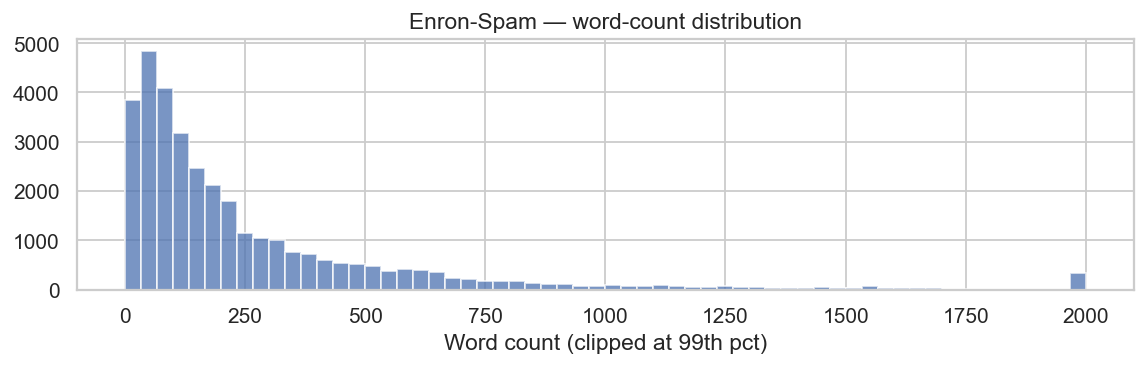


Label (label):
  spam                 17,171  ( 50.9%)  ████████████████████████████████████████
  ham                  16,545  ( 49.1%)  ██████████████████████████████████████

Temporal (33,716/33,716 records dated,  span 2000–2000):
  2000: 33,716  ████████████████████████████████████████

Email headers  — subject: 33,428/33,716   from: 0/33,716

─────────────────────────  3 random samples  ─────────────────────────

── 1  [196w]  {'label': 'spam', 'subset': 'enron2', 'subject': '', 'from': '', 'date': '', 'has_url': False, 'url_count': 0, 'collection_period': '2000-2002'}
http : / / www . virtu  ally - anywhere . com / sports /  hello ,  i was hoping you could help me .
the link above takes  you to  several  facility stadiumtours created by virtually  anywhere
interactive . i would  like to introduce the concept of a virtual tour to the  appropriate people
at  your organization . ( our current customers ' premium  seating and ticket  sales ,  marketing ,
pr and b
  [...]

── 2  [12

In [74]:
# ── 3b. Analyze Enron ─────────────────────────────────────────────────────
analyze_source(enron_records, "Enron-Spam", label_key="label")

SCAM_419_KW = [
    "beneficiary", "inheritance", "next of kin", "deceased",
    "transfer of funds", "million dollar", "barrister", "attorney",
    "strictly confidential", "late client", "foreign account",
    "funds transfer", "oil contract", "dear friend", "dearest beloved",
    "good day", "am contacting you",
]
enron_spam = [r for r in enron_records if r["label"] == "spam"]
n419 = sum(1 for r in enron_spam
           if any(kw in r["text"].lower() for kw in SCAM_419_KW))
print(f"\n── 419-style keyword filter (spam) ──")
print(f"  Spam with 419 keywords: {n419:,}/{len(enron_spam):,} "
      f"({100*n419/max(len(enron_spam),1):.1f}%) → candidate scam_419 sub-corpus")

print("\n── Stratification notes ──────────────────────────────────────────────")
print("  ✅ Axis: LABEL (spam/ham)")
print("  ✅ Axis: 419 keyword sub-filter → scam_419 content type")
print("  ✅ Axis: SUBJECT, FROM headers available")
print("  Role: spam(419)→A scam_419,  ham→B legitimate_email")
print("  ⚠️  Era 2000–2002 — highest temporal-bias risk; ~22yr gap vs LLM 2024–2025")

---
## 4 · SpamAssassin Public Corpus

**Source:** https://spamassassin.apache.org/old/publiccorpus/  
**Era:** 2003–2005  
**Candidate roles:** spam → Human+Fraud,  ham → Human+Legit  

**Stratification axes available:**
- `label` (spam/ham)
- `archive` — 2003 vs 2005 sub-split
- `has_url` / `url_count`
- `subject` / `from` headers

In [75]:
# ── 4a. Download SpamAssassin ─────────────────────────────────────────────
SA_CACHE = COLLECTED / "spamassassin.jsonl"
SA_ARCHIVES = [
    ("https://spamassassin.apache.org/old/publiccorpus/20030228_spam.tar.bz2",      "spam"),
    ("https://spamassassin.apache.org/old/publiccorpus/20030228_spam_2.tar.bz2",    "spam"),
    ("https://spamassassin.apache.org/old/publiccorpus/20050311_spam_2.tar.bz2",    "spam"),
    ("https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham.tar.bz2",  "ham"),
    ("https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham_2.tar.bz2","ham"),
]


def _parse_sa_archive(url: str, label: str) -> list[dict]:
    arch = url.split("/")[-1]
    print(f"  {arch} ...", end=" ", flush=True)
    try:
        resp = httpx.get(url, timeout=60, follow_redirects=True)
        resp.raise_for_status()
    except Exception as e:
        print(f"FAILED ({e})"); return []
    from email import message_from_string as _mfs
    records = []
    with tarfile.open(fileobj=io.BytesIO(resp.content), mode="r:bz2") as tar:
        for member in tar.getmembers():
            if not member.isfile() or member.name.endswith("cmds"):
                continue
            try:
                raw  = tar.extractfile(member).read().decode("utf-8", errors="replace")
                body = extract_email_body(raw).strip()
                m    = _mfs(raw)
                subj = _sanitize(str(m.get("Subject", "")))
                frm  = _sanitize(str(m.get("From", "")))
                date = str(m.get("Date", ""))
            except Exception:
                continue
            has_url, n_url = url_meta(body)
            records.append({
                "text":              body,
                "label":             label,
                "archive":           arch,
                "subject":           subj,
                "from":              frm,
                "date":              date,
                "has_url":           has_url,
                "url_count":         n_url,
                "collection_period": "2003-2005",
            })
    print(f"{len(records):,} records")
    return records


if SA_CACHE.exists():
    print(f"Cache: {SA_CACHE}")
    sa_records = load_jsonl(SA_CACHE)
else:
    sa_records = []
    for url, label in SA_ARCHIVES:
        sa_records += _parse_sa_archive(url, label)
    save_jsonl(sa_records, SA_CACHE)

print(f"\nSpamAssassin raw total: {len(sa_records):,}")

  20030228_spam.tar.bz2 ... 500 records
  20030228_spam_2.tar.bz2 ... 1,397 records
  20050311_spam_2.tar.bz2 ... 1,396 records
  20030228_easy_ham.tar.bz2 ... 2,500 records
  20030228_easy_ham_2.tar.bz2 ... 1,400 records
Saved 7,193 records → /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected/spamassassin.jsonl

SpamAssassin raw total: 7,193



  SpamAssassin
Total records  : 7,193
Fields         : ['archive', 'collection_period', 'date', 'from', 'has_url', 'label', 'subject', 'text', 'url_count']
Unique texts   : 5,491  (dup rate 23.7% — file unchanged)
Noisy >2%\ufffd : 18  (0.3%)
Short <10 words: 193  (2.7%)
Has URL        : 5,137  (71.4%),  avg 1.9 URLs/record

Word count distribution:


count     7193.0
mean       269.6
std        613.3
min          0.0
10%         35.0
25%         81.0
50%        144.0
75%        257.0
90%        493.8
95%        754.2
max      14954.0
Name: n_words, dtype: float64

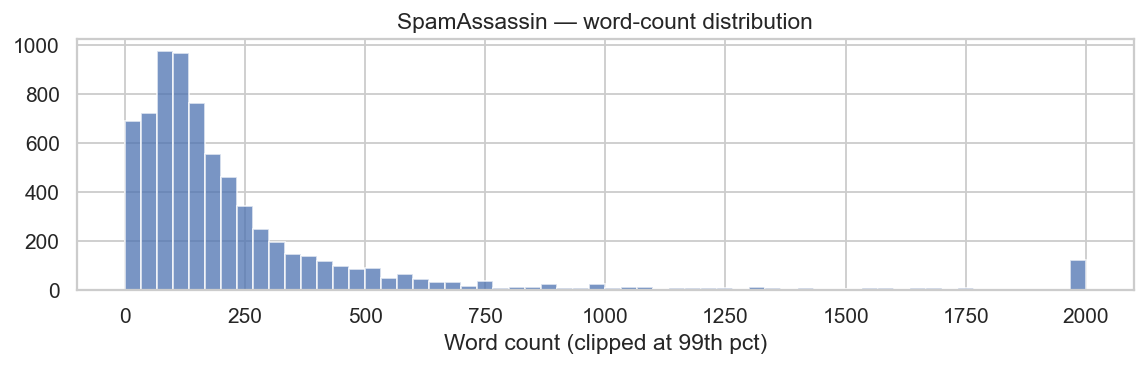


Label (label):
  ham                   3,900  ( 54.2%)  ████████████████████████████████████████
  spam                  3,293  ( 45.8%)  █████████████████████████████████

Temporal (7,193/7,193 records dated,  span 1997–2028):
  1997:     2  █
  1998:     2  █
  1999:     2  █
  2000:     8  █
  2001:   268  █
  2002: 6,739  ████████████████████████████████████████
  2003:   168  █
  2020:     3  █
  2028:     1  █

Email headers  — subject: 7,164/7,193   from: 7,191/7,193

─────────────────────────  3 random samples  ─────────────────────────

── 1  [117w]  {'label': 'spam', 'archive': '20050311_spam_2.tar.bz2', 'subject': 'Personal Alcohol Detector', 'from': 'hdtrade@dreamwiz.com', 'date': 'Mon, 3 Jun 2002 17:06:35 +0900', 'has_url': True, 'url_count': 1, 'collection_period': '2003-2005'}
For your safe drive...and keep your safety with Personal Alcohol Detector.. The key technology for
the function and performance of Personal Alcohol Detector is the gas sensor. We use Advanced MEMS

In [76]:
# ── 4b. Analyze SpamAssassin ──────────────────────────────────────────────
analyze_source(sa_records, "SpamAssassin", label_key="label")

sa_spam = [r for r in sa_records if r["label"] == "spam"]
n419_sa = sum(1 for r in sa_spam
              if any(kw in r["text"].lower() for kw in SCAM_419_KW))
print(f"\n── 419-style keywords in SA spam: {n419_sa}/{len(sa_spam)} "
      f"({100*n419_sa/max(len(sa_spam),1):.1f}%)")

print("\n── Stratification notes ──────────────────────────────────────────────")
print("  ✅ Axis: LABEL (spam/ham),  ARCHIVE (2003 vs 2005)")
print("  ✅ Axis: SUBJECT, FROM headers available")
print("  Role: backup/validation corpus alongside Enron")
print("  ⚠️  Era 2003–2005 — same temporal gap as Enron")

---
## 5 · HC3 Finance Domain

**Source:** HuggingFace `Hello-SimpleAI/HC3` → `finance.jsonl`  
**Reference:** Guo et al. 2023  
**Content:** Financial forum Q&A — human answers vs ChatGPT answers  
**Classification:** Legitimate (not fraudulent)

**Candidate roles:**
- Human answers → Group B (Human+Legit) `financial_qa`
- ChatGPT answers → Group D (LLM+Legit) `financial_qa` ← **native bilateral pair**

**Stratification axes available:**
- `role` (human/chatgpt) — authorship label
- `question_id` — topic control (same question, two authors)
- `has_url` / `url_count`
- Length: ChatGPT answers systematically longer

In [77]:
# ── 5a. Download HC3 Finance ──────────────────────────────────────────────
HC3F_CACHE = COLLECTED / "hc3_finance.jsonl"
HC3_BASE   = "https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main"

if HC3F_CACHE.exists():
    print(f"Cache: {HC3F_CACHE}")
    hc3_fin_records = load_jsonl(HC3F_CACHE)
else:
    url = f"{HC3_BASE}/finance.jsonl"
    print(f"Downloading {url} ...")
    resp = httpx.get(url, timeout=60, follow_redirects=True)
    resp.raise_for_status()
    hc3_fin_raw = [json.loads(l) for l in resp.text.splitlines() if l.strip()]
    hc3_fin_records = []
    for idx, item in enumerate(hc3_fin_raw):
        q = str(item.get("question", ""))[:200]
        for a in item.get("human_answers", []):
            text = str(a).strip()
            if not text:
                continue
            has_url, n_url = url_meta(text)
            hc3_fin_records.append({
                "text":              text,
                "role":              "human",
                "question":          q,
                "question_id":       idx,
                "has_url":           has_url,
                "url_count":         n_url,
                "collection_period": "2008-2022",
            })
        for a in item.get("chatgpt_answers", []):
            text = str(a).strip()
            if not text:
                continue
            has_url, n_url = url_meta(text)
            hc3_fin_records.append({
                "text":              text,
                "role":              "chatgpt",
                "question":          q,
                "question_id":       idx,
                "has_url":           has_url,
                "url_count":         n_url,
                "collection_period": "2022-2023",
            })
    save_jsonl(hc3_fin_records, HC3F_CACHE)

print(f"HC3 Finance total: {len(hc3_fin_records):,}")

Saved 8,436 records → /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected/hc3_finance.jsonl
HC3 Finance total: 8,436



  HC3 Finance
Total records  : 8,436
Fields         : ['collection_period', 'has_url', 'question', 'question_id', 'role', 'text', 'url_count']
Unique texts   : 8,395  (dup rate 0.5% — file unchanged)
Noisy >2%\ufffd : 0  (0.0%)
Short <10 words: 24  (0.3%)
Has URL        : 279  (3.3%),  avg 0.0 URLs/record

Word count distribution:


count    8436.0
mean      190.7
std       120.2
min         1.0
10%        57.0
25%       115.0
50%       186.0
75%       242.0
90%       301.0
95%       362.2
max      1629.0
Name: n_words, dtype: float64

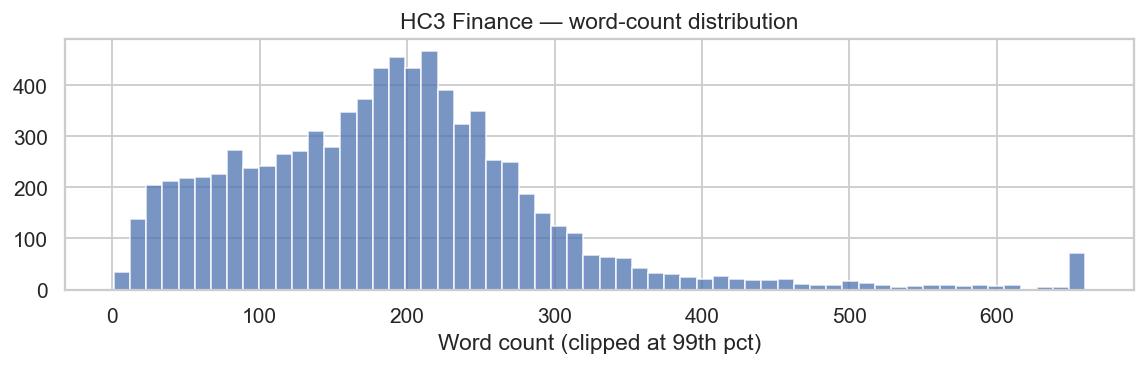


Label (role):
  chatgpt               4,503  ( 53.4%)  ████████████████████████████████████████
  human                 3,933  ( 46.6%)  ██████████████████████████████████

Temporal (8,436/8,436 records dated,  span 2008–2022):
  2008: 3,933  ██████████████████████████████████
  2022: 4,503  ████████████████████████████████████████

─────────────────────────  3 random samples  ─────────────────────────

── 1  [192w]  {'role': 'chatgpt', 'question': 'GAAP or non-GAAP numbers in nasdaq.com?', 'question_id': 1501, 'has_url': False, 'url_count': 0, 'collection_period': '2022-2023'}
GAAP stands for Generally Accepted Accounting Principles, and it refers to the standard framework of
guidelines used in the preparation of financial statements in the United States. Non-GAAP financial
measures, on the other hand, are financial measures that are not prepared in accordance with GAAP.On
NASDAQ.com, you may come across both GAAP and non-GAAP financial measures for a company. It's impo
  [...]

── 2

In [78]:
# ── 5b. Analyze HC3 Finance ───────────────────────────────────────────────
analyze_source(hc3_fin_records, "HC3 Finance", label_key="role")

# Paired example
fin_by_qid: dict[int, dict] = {}
for r in hc3_fin_records:
    qid = r["question_id"]
    if qid not in fin_by_qid:
        fin_by_qid[qid] = {"q": r["question"], "human": None, "chatgpt": None}
    fin_by_qid[qid][r["role"]] = r["text"]
paired = [(v["q"], v["human"], v["chatgpt"])
          for v in fin_by_qid.values()
          if v["human"] and v["chatgpt"]]
if paired:
    q, h, g = random.choice(paired)
    print(f"\n── Paired example ────────────────────────────────────────────────")
    print(f"Q: {q[:200]}")
    print(f"\nHuman   ({word_count(h)}w): {h[:300]}")
    print(f"\nChatGPT ({word_count(g)}w): {g[:300]}")
    print(f"\nPaired QA items: {len(paired):,}")

print("\n── Stratification notes ──────────────────────────────────────────────")
print("  ✅ NATIVE bilateral pair — same question answered by both sides")
print("  ✅ Axis: ROLE (human/chatgpt)")
print("  ✅ Axis: QUESTION_ID — topic-controlled pairs")
print("  Role: B (Human+Legit) + D (LLM+Legit) → financial_qa")
print("  ⚠️  Fix from v1: HC3 was incorrectly placed in Group A/C (fraud)")

---
## 6 · HC3 Open QA Domain

**Source:** HuggingFace `Hello-SimpleAI/HC3` → `open_qa.jsonl`  
**Content:** General knowledge Q&A (not finance-specific)  

**Key question for dataset design:**  
Is general Q&A relevant to an anti-fraud detector? Risk: off-domain noise.

In [79]:
# ── 6a. Download HC3 Open QA ──────────────────────────────────────────────
HC3Q_CACHE = COLLECTED / "hc3_open_qa.jsonl"

if HC3Q_CACHE.exists():
    print(f"Cache: {HC3Q_CACHE}")
    hc3_qa_records = load_jsonl(HC3Q_CACHE)
else:
    url = f"{HC3_BASE}/open_qa.jsonl"
    print(f"Downloading {url} ...")
    resp = httpx.get(url, timeout=60, follow_redirects=True)
    resp.raise_for_status()
    hc3_qa_raw = [json.loads(l) for l in resp.text.splitlines() if l.strip()]
    hc3_qa_records = []
    for idx, item in enumerate(hc3_qa_raw):
        q = str(item.get("question", ""))[:200]
        for role, key in (("human", "human_answers"), ("chatgpt", "chatgpt_answers")):
            period = "2008-2022" if role == "human" else "2022-2023"
            for a in item.get(key, []):
                text = str(a).strip()
                if not text:
                    continue
                has_url, n_url = url_meta(text)
                hc3_qa_records.append({
                    "text":              text,
                    "role":              role,
                    "question":          q,
                    "question_id":       idx,
                    "has_url":           has_url,
                    "url_count":         n_url,
                    "collection_period": period,
                })
    save_jsonl(hc3_qa_records, HC3Q_CACHE)

print(f"HC3 Open QA total: {len(hc3_qa_records):,}")

Saved 4,733 records → /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/collected/hc3_open_qa.jsonl
HC3 Open QA total: 4,733



  HC3 Open QA
Total records  : 4,733
Fields         : ['collection_period', 'has_url', 'question', 'question_id', 'role', 'text', 'url_count']
Unique texts   : 4,689  (dup rate 0.9% — file unchanged)
Noisy >2%\ufffd : 0  (0.0%)
Short <10 words: 70  (1.5%)
Has URL        : 1  (0.0%),  avg 0.0 URLs/record

Word count distribution:


count    4733.0
mean       96.5
std        65.0
min         2.0
10%        22.0
25%        42.0
50%        88.0
75%       133.0
90%       189.0
95%       216.0
max       595.0
Name: n_words, dtype: float64

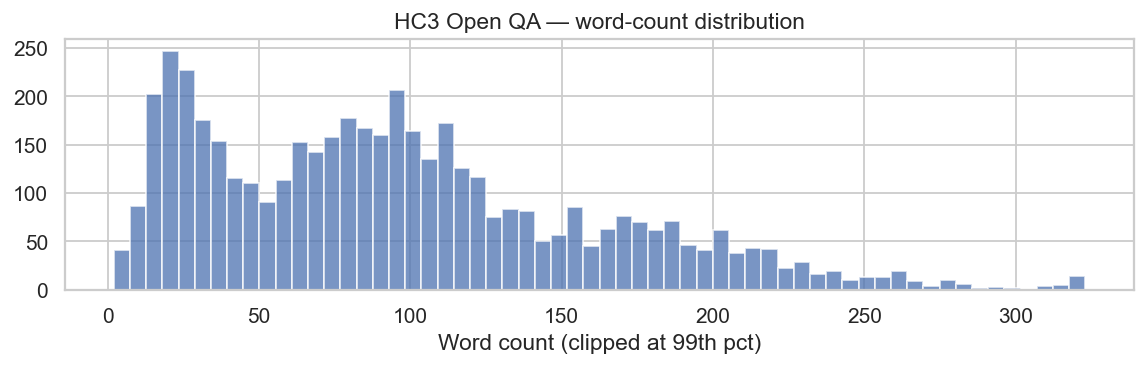


Label (role):
  chatgpt               3,546  ( 74.9%)  ████████████████████████████████████████
  human                 1,187  ( 25.1%)  █████████████

Temporal (4,733/4,733 records dated,  span 2008–2022):
  2008: 1,187  █████████████
  2022: 3,546  ████████████████████████████████████████

─────────────────────────  3 random samples  ─────────────────────────

── 1  [23w]  {'role': 'human', 'question': 'when does air bag deploy', 'question_id': 928, 'has_url': False, 'url_count': 0, 'collection_period': '2008-2022'}
It is an occupant restraint system consisting of a flexible fabric envelope or cushion designed to
inflate rapidly during an automobile collision .

── 2  [106w]  {'role': 'chatgpt', 'question': 'what is the definition of a hung jury', 'question_id': 571, 'has_url': False, 'url_count': 0, 'collection_period': '2022-2023'}
A hung jury is a jury that is unable to reach a verdict in a trial because they are unable to agree
on a verdict. This can occur when there is not enou

In [80]:
# ── 6b. Analyze HC3 Open QA ───────────────────────────────────────────────
analyze_source(hc3_qa_records, "HC3 Open QA", label_key="role")

hc3_qa_raw_local = load_jsonl(HC3Q_CACHE) if HC3Q_CACHE.exists() else []
all_questions = list({r["question"] for r in hc3_qa_records})
print("\n── 10 sample questions (domain-relevance check) ─────────────────────")
for i, q in enumerate(random.sample(all_questions, min(10, len(all_questions))), 1):
    print(f"  {i:2}. {q[:110]}")

print("\n── Stratification notes ──────────────────────────────────────────────")
print("  Axis: ROLE (human/chatgpt)")
print("  Domain: GENERAL — not anti-fraud specific")
print("  Decision: include only if domain-agnostic baseline is needed")
print("  Risk: off-domain noise; may dilute authorship signal in fraud context")

---
## 7 · Summary — Counts, Duplication, Temporal Coverage & Stratification Axes

In [81]:
# ── 7a. Source comparison table ───────────────────────────────────────────

def _unique(recs: list[dict]) -> int:
    return len({hashlib.md5(r["text"].strip().encode("utf-8", errors="replace")).hexdigest()
                for r in recs})

def _med_wc(recs: list[dict]) -> str:
    if not recs: return "—"
    vals = sorted(word_count(r["text"]) for r in recs)
    return str(vals[len(vals) // 2])

def _yr_span(recs: list[dict]) -> str:
    yrs = []
    for r in recs:
        for f in ("date", "collection_period", "source", "archive"):
            m = _YEAR_RE.search(str(r.get(f, "")))
            if m:
                yrs.append(int(m.group())); break
    return f"{min(yrs)}–{max(yrs)}" if yrs else "?"

def _url_pct(recs: list[dict]) -> str:
    if not recs: return "—"
    return f"{100*sum(r.get('has_url',False) for r in recs)/len(recs):.0f}%"


corpora = [
    ("Nazario",                  nazario_records,
     "Human", "Fraud",  "phishing_email",  "A"),
    ("SMS spam",                 [r for r in sms_records if r.get("label")=="spam"],
     "Human", "Fraud",  "smishing",        "A"),
    ("SMS ham",                  [r for r in sms_records if r.get("label")=="ham"],
     "Human", "Legit",  "legitimate_sms",  "B"),
    ("Enron spam (419 filter)",  [r for r in enron_records
                                  if r.get("label")=="spam"
                                  and any(kw in r["text"].lower() for kw in SCAM_419_KW)],
     "Human", "Fraud",  "scam_419",        "A"),
    ("Enron ham",                [r for r in enron_records if r.get("label")=="ham"],
     "Human", "Legit",  "legitimate_email","B"),
    ("SpamAssassin spam",        [r for r in sa_records if r.get("label")=="spam"],
     "Human", "Fraud",  "general_spam",    "A?"),
    ("SpamAssassin ham",         [r for r in sa_records if r.get("label")=="ham"],
     "Human", "Legit",  "legitimate_email","B"),
    ("HC3 Finance (human)",      [r for r in hc3_fin_records if r.get("role")=="human"],
     "Human", "Legit",  "financial_qa",    "B"),
    ("HC3 Finance (chatgpt)",    [r for r in hc3_fin_records if r.get("role")=="chatgpt"],
     "LLM",   "Legit",  "financial_qa",    "D"),
    ("HC3 Open QA (human)",      [r for r in hc3_qa_records if r.get("role")=="human"],
     "Human", "Legit",  "open_qa",         "B?"),
    ("HC3 Open QA (chatgpt)",    [r for r in hc3_qa_records if r.get("role")=="chatgpt"],
     "LLM",   "Legit",  "open_qa",         "D?"),
]

rows = []
for name, recs, author, fraud, ctype, group in corpora:
    if not recs:
        rows.append((name, 0, 0, "—", "—", "—", author, fraud, ctype, group))
        continue
    n = len(recs)
    u = _unique(recs)
    rows.append((
        name, n, u,
        f"{100*(n-u)/max(n,1):.0f}%",
        _yr_span(recs),
        _med_wc(recs),
        _url_pct(recs),
        author, fraud, ctype, group,
    ))

df_sum = pd.DataFrame(rows, columns=[
    "Source", "N_raw", "N_unique", "Dup%",
    "Year_span", "Med_words", "URL%",
    "Author", "Fraud_Legit", "content_type", "Group",
])
display(df_sum.to_string(index=False))
df_sum.to_csv(OUT_TABLES / "source_summary.csv", index=False)
print(f"\nSaved → {OUT_TABLES / 'source_summary.csv'}")

'                 Source  N_raw  N_unique Dup% Year_span Med_words URL% Author Fraud_Legit     content_type Group\n                Nazario   8472      5820  31% 1999–2025       136  48%  Human       Fraud   phishing_email     A\n               SMS spam    747       642  14% 2006–2006        25   3%  Human       Fraud         smishing     A\n                SMS ham   4827      4518   6% 2006–2006        11   0%  Human       Legit   legitimate_sms     B\nEnron spam (419 filter)    872       731  16% 2000–2000       513   0%  Human       Fraud         scam_419     A\n              Enron ham  16545     15794   5% 2000–2000       169   0%  Human       Legit legitimate_email     B\n      SpamAssassin spam   3293      1630  51% 1997–2020       154  54%  Human       Fraud     general_spam    A?\n       SpamAssassin ham   3900      3861   1% 2002–2028       137  86%  Human       Legit legitimate_email     B\n    HC3 Finance (human)   3933      3933   0% 2008–2008       129   7%  Human       Leg


Saved → /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/tables/source_summary.csv


In [82]:
# ── 7b. Stratification axes + dataset design recommendations ─────────────
print("""
STRATIFICATION AXES FOR DATASET DESIGN
=======================================

Axis 1 · AUTHORSHIP  (primary label)
  0 = Human-written
  1 = LLM-generated
  All human sources here; LLM side generated via prompting.

Axis 2 · FRAUD / LEGIT
  fraud = intended to deceive
  legit = normal / benign communication

Axis 3 · CONTENT TYPE
  phishing_email    — Nazario                        (Group A)
  smishing          — SMS spam                       (Group A)
  scam_419          — Enron spam (419 filter)        (Group A)
  financial_qa      — HC3 Finance  (bilateral pair!) (Groups B+D)
  legitimate_email  — Enron ham, SA ham              (Group B)
  legitimate_sms    — SMS ham                        (Group B)

Axis 4 · TEXT LENGTH BIN
  short  : ≤ 50 words
  medium : 51–200 words
  long   : > 200 words
  → Check Med_words per source above; SMS anchors the 'short' bin.

Axis 5 · ERA  (temporal)
  pre-2010 : Enron, SpamAssassin, Nazario legacy
  2010-2020: Nazario 2015-2019, HC3 human
  2020+    : Nazario 2020-2025, HC3 ChatGPT
  LLM texts will be 2024–2025 → weight recent Nazario for phishing_email.

Axis 6 · URL PRESENCE
  has_url = True/False
  url_count (numeric)
  → Phishing emails are URL-heavy; legitimate emails less so.
  → Can be a diagnostic feature, not just a stratification axis.

BILATERAL PAIRS
===============
  ✅ phishing_email — Nazario (human) + generate LLM
  ✅ smishing       — SMS spam (human) + generate LLM
  ✅ scam_419       — Enron 419 filter (human) + generate LLM
  ✅ financial_qa   — HC3 Finance NATIVE bilateral pair
  ⚠️  legitimate_email — human present; LLM side needed
  ⚠️  bank_notification, social_engineering — LLM-only in v1

KEY RISKS
=========
  1. Temporal bias: Enron/SA (2000–2005) vs LLM (2024–2025) → ~22yr gap
     Mitigation: use Nazario 2020–2025 as primary phishing source.
  2. Genre monopoly: some content types in one class only.
     Mitigation: document and run bilateral sub-experiment.
  3. Enron general spam: too broad; restrict to 419 filter.
""")


STRATIFICATION AXES FOR DATASET DESIGN

Axis 1 · AUTHORSHIP  (primary label)
  0 = Human-written
  1 = LLM-generated
  All human sources here; LLM side generated via prompting.

Axis 2 · FRAUD / LEGIT
  fraud = intended to deceive
  legit = normal / benign communication

Axis 3 · CONTENT TYPE
  phishing_email    — Nazario                        (Group A)
  smishing          — SMS spam                       (Group A)
  scam_419          — Enron spam (419 filter)        (Group A)
  financial_qa      — HC3 Finance  (bilateral pair!) (Groups B+D)
  legitimate_email  — Enron ham, SA ham              (Group B)
  legitimate_sms    — SMS ham                        (Group B)

Axis 4 · TEXT LENGTH BIN
  short  : ≤ 50 words
  medium : 51–200 words
  long   : > 200 words
  → Check Med_words per source above; SMS anchors the 'short' bin.

Axis 5 · ERA  (temporal)
  pre-2010 : Enron, SpamAssassin, Nazario legacy
  2010-2020: Nazario 2015-2019, HC3 human
  2020+    : Nazario 2020-2025, HC3 ChatGPT
 